# Data Loading and Package Setup
This section installs the required R packages, loads the libraries, imports the insurance dataset, and displays the first few records to verify that the data has been loaded correctly.

In [1]:
install.packages("tidyverse")
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(tidyverse)
library(randomForest)

df <- read.csv("insurance.csv")

head(df)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


# Predicting Medical Insurance Charges Using Machine Learning

## Business Question

Which factors have the greatest impact on medical insurance charges, and which machine learning model predicts insurance costs most accurately?

## Business Objective

The objective of this project is to identify the key factors influencing insurance charges and compare the performance of different machine learning models in predicting medical costs. The findings can support insurance companies in improving pricing strategies and understanding customer risk profiles.

# Data Exploration

Before building any machine learning model, it is important to understand the dataset, inspect its structure, identify missing values, and summarize the variables.

In [3]:
# Dataset dimensions
dim(df)

# Structure of the dataset
str(df)

# Summary statistics
summary(df)

[1] 1338    7

'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : chr  "female" "male" "male" "male" ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : chr  "yes" "no" "no" "no" ...
 $ region  : chr  "southwest" "southeast" "southeast" "northwest" ...
 $ charges : num  16885 1726 4449 21984 3867 ...


      age               sex            bmi           children    
 Min.   :18.00   Length   :1338   Min.   :15.96   Min.   :0.000  
 1st Qu.:27.00   N.unique :   2   1st Qu.:26.30   1st Qu.:0.000  
 Median :39.00   N.blank  :   0   Median :30.40   Median :1.000  
 Mean   :39.21   Min.nchar:   4   Mean   :30.66   Mean   :1.095  
 3rd Qu.:51.00   Max.nchar:   6   3rd Qu.:34.69   3rd Qu.:2.000  
 Max.   :64.00                    Max.   :53.13   Max.   :5.000  
       smoker           region        charges     
 Length   :1338   Length   :1338   Min.   : 1122  
 N.unique :   2   N.unique :   4   1st Qu.: 4740  
 N.blank  :   0   N.blank  :   0   Median : 9382  
 Min.nchar:   2   Min.nchar:   9   Mean   :13270  
 Max.nchar:   3   Max.nchar:   9   3rd Qu.:16640  
                                   Max.   :63770  

In [4]:
# Check for missing values
colSums(is.na(df))

age      sex      bmi children   smoker   region  charges 
       0        0        0        0        0        0        0

# Exploratory Data Analysis (EDA)

In this section, we explore the dataset visually to understand the relationships between variables and identify the main factors that influence insurance charges.

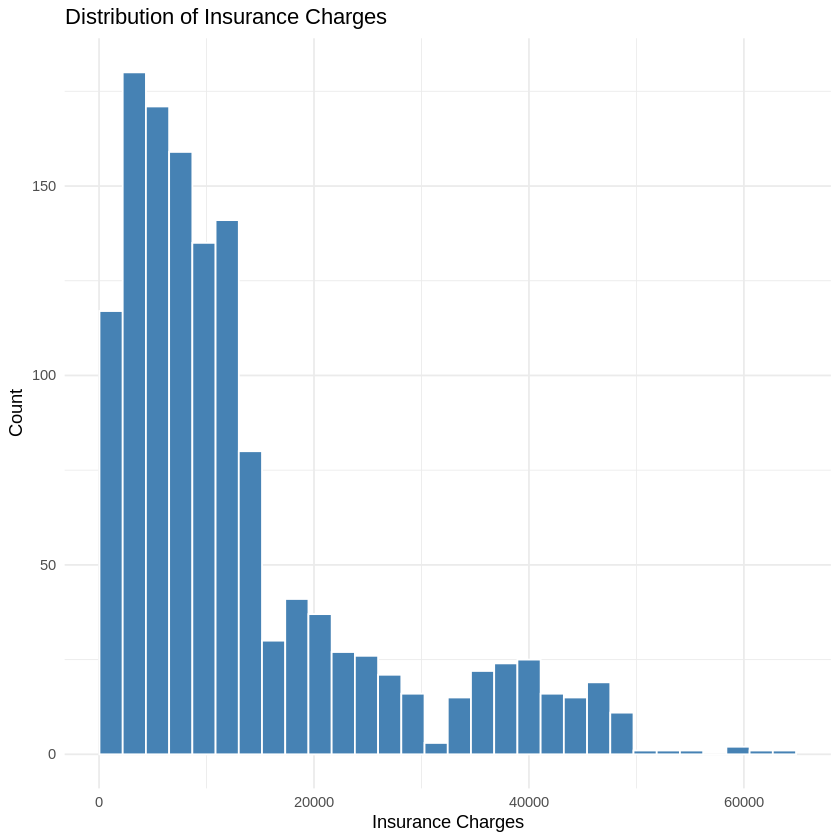

In [5]:
ggplot(df, aes(x = charges)) +
  geom_histogram(bins = 30,
                 fill = "steelblue",
                 color = "white") +
  labs(title = "Distribution of Insurance Charges",
       x = "Insurance Charges",
       y = "Count") +
  theme_minimal()

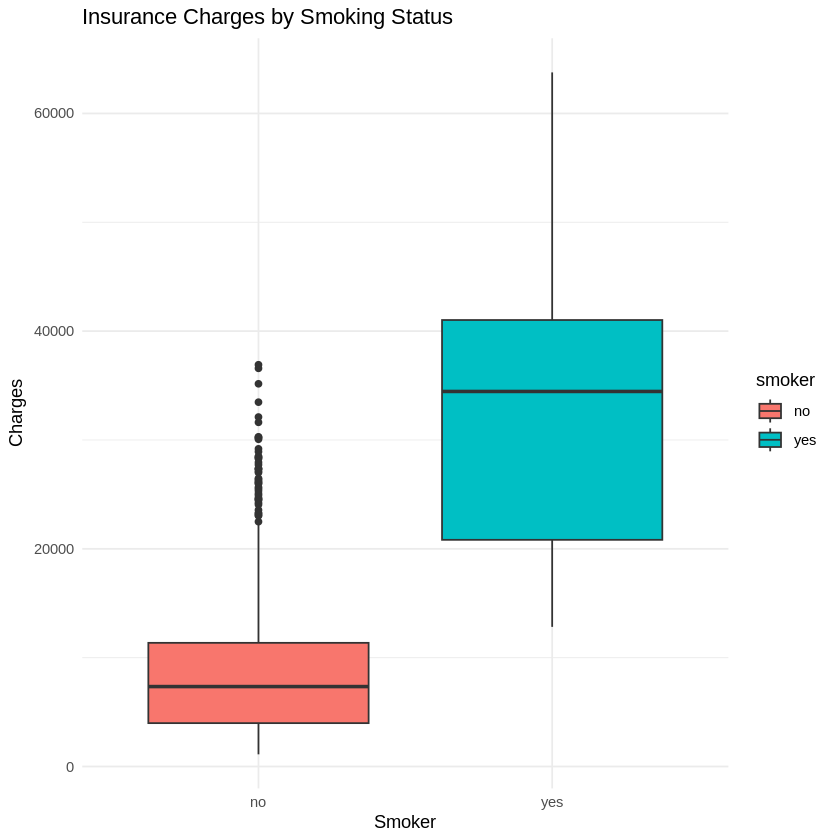

In [6]:
ggplot(df, aes(x = smoker,
               y = charges,
               fill = smoker)) +
  geom_boxplot() +
  labs(title = "Insurance Charges by Smoking Status",
       x = "Smoker",
       y = "Charges") +
  theme_minimal()

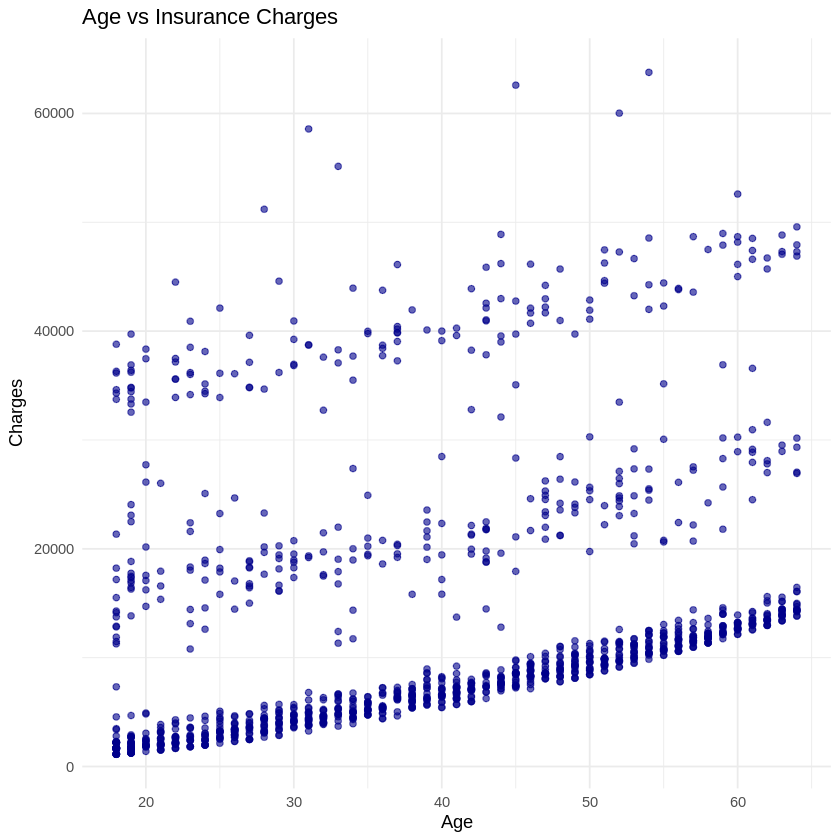

In [7]:
ggplot(df, aes(x = age,
               y = charges)) +
  geom_point(color = "darkblue",
             alpha = 0.6) +
  labs(title = "Age vs Insurance Charges",
       x = "Age",
       y = "Charges") +
  theme_minimal()

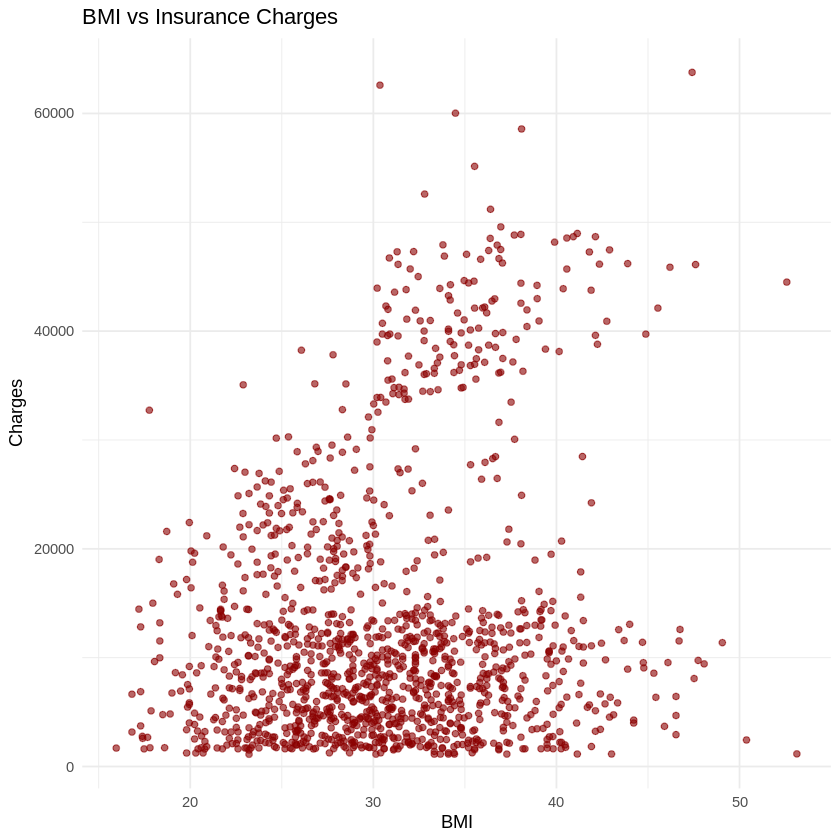

In [8]:
ggplot(df, aes(x = bmi,
               y = charges)) +
  geom_point(color = "darkred",
             alpha = 0.6) +
  labs(title = "BMI vs Insurance Charges",
       x = "BMI",
       y = "Charges") +
  theme_minimal()

# Data Preparation

Before training the machine learning models, the categorical variables are converted into factors. The dataset is then divided into training and testing sets to evaluate model performance on unseen data.

In [9]:
# Convert categorical variables to factors
df$sex <- as.factor(df$sex)
df$smoker <- as.factor(df$smoker)
df$region <- as.factor(df$region)

str(df)

'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : Factor w/ 2 levels "female","male": 1 2 2 2 2 1 1 1 2 1 ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : Factor w/ 2 levels "no","yes": 2 1 1 1 1 1 1 1 1 1 ...
 $ region  : Factor w/ 4 levels "northeast","northwest",..: 4 3 3 2 2 3 3 2 1 2 ...
 $ charges : num  16885 1726 4449 21984 3867 ...


In [10]:
set.seed(123)

train_index <- sample(1:nrow(df), 0.8 * nrow(df))

train_data <- df[train_index, ]
test_data  <- df[-train_index, ]

dim(train_data)
dim(test_data)

[1] 1070    7

[1] 268   7

# Model 1: Linear Regression

Linear Regression is used as a baseline model to predict insurance charges. It assumes a linear relationship between the predictor variables and the target variable.

In [11]:
# Train Linear Regression model
lm_model <- lm(charges ~ ., data = train_data)

# Model summary
summary(lm_model)


Call:
lm(formula = charges ~ ., data = train_data)

Residuals:
   Min     1Q Median     3Q    Max 
-11297  -2846  -1005   1542  29791 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -12031.63    1132.08 -10.628  < 2e-16 ***
age                243.43      13.65  17.834  < 2e-16 ***
sexmale           -216.88     378.52  -0.573 0.566792    
bmi                355.06      32.62  10.884  < 2e-16 ***
children           559.84     156.28   3.582 0.000356 ***
smokeryes        24172.29     459.97  52.552  < 2e-16 ***
regionnorthwest   -556.52     539.58  -1.031 0.302594    
regionsoutheast   -856.23     541.73  -1.581 0.114281    
regionsouthwest   -967.82     541.96  -1.786 0.074421 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6145 on 1061 degrees of freedom
Multiple R-squared:  0.7533,	Adjusted R-squared:  0.7514 
F-statistic: 404.9 on 8 and 1061 DF,  p-value: < 2.2e-16


In [12]:
# Predictions
lm_predictions <- predict(lm_model, test_data)

In [13]:
# Calculate performance metrics

MAE <- mean(abs(test_data$charges - lm_predictions))

RMSE <- sqrt(mean((test_data$charges - lm_predictions)^2))

R2 <- cor(test_data$charges, lm_predictions)^2

cat("MAE =", MAE, "\n")
cat("RMSE =", RMSE, "\n")
cat("R-squared =", R2)

MAE = 3940.185 
RMSE = 5763.385 
R-squared = 0.7339413

# Model 2: Random Forest

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy. It can capture complex relationships in the data better than a simple linear model.

In [14]:
# Train Random Forest model

rf_model <- randomForest(
  charges ~ .,
  data = train_data,
  ntree = 500,
  importance = TRUE
)

print(rf_model)


Call:
 randomForest(formula = charges ~ ., data = train_data, ntree = 500,      importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 2

          Mean of squared residuals: 23509309
                    % Var explained: 84.51


In [15]:
rf_predictions <- predict(rf_model, test_data)

In [16]:
rf_MAE <- mean(abs(test_data$charges - rf_predictions))

rf_RMSE <- sqrt(mean((test_data$charges - rf_predictions)^2))

rf_R2 <- cor(test_data$charges, rf_predictions)^2

cat("MAE =", rf_MAE, "\n")
cat("RMSE =", rf_RMSE, "\n")
cat("R-squared =", rf_R2)

MAE = 2831.016 
RMSE = 4396.185 
R-squared = 0.8500731

In [17]:
# Train Random Forest model

rf_model <- randomForest(
  charges ~ .,
  data = train_data,
  ntree = 500,
  importance = TRUE
)

print(rf_model)


Call:
 randomForest(formula = charges ~ ., data = train_data, ntree = 500,      importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 2

          Mean of squared residuals: 23505906
                    % Var explained: 84.51


In [18]:
rf_predictions <- predict(rf_model, test_data)

In [19]:
rf_MAE <- mean(abs(test_data$charges - rf_predictions))

rf_RMSE <- sqrt(mean((test_data$charges - rf_predictions)^2))

rf_R2 <- cor(test_data$charges, rf_predictions)^2

cat("MAE =", rf_MAE, "\n")
cat("RMSE =", rf_RMSE, "\n")
cat("R-squared =", rf_R2)

MAE = 2801.824 
RMSE = 4396.833 
R-squared = 0.8492443

# Feature Importance

To understand which variables have the greatest influence on insurance charges, we examine the feature importance scores generated by the Random Forest model.

,%IncMSE,IncNodePurity
age,65.0072557,19313394998
sex,-0.4401674,1136533221
bmi,64.4486960,22905125016
children,9.4648035,3468753684
smoker,172.1004157,99156617307
region,2.8476262,3284755967


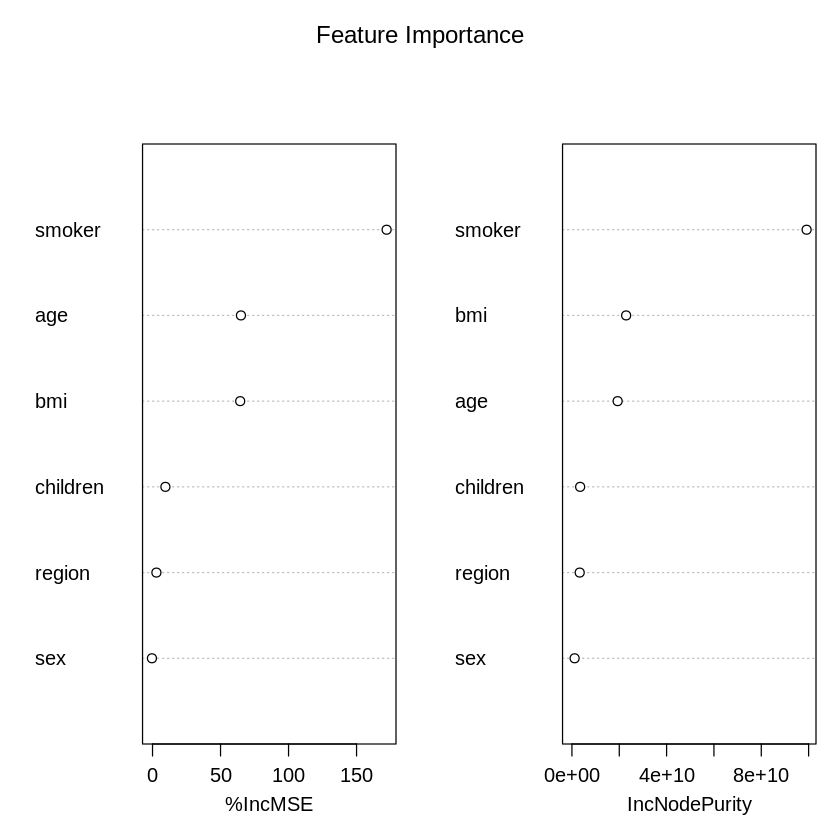

In [20]:
# Plot Feature Importance

importance(rf_model)

varImpPlot(
  rf_model,
  main = "Feature Importance"
)

# Model Comparison

The performance of the two machine learning models was compared using MAE, RMSE, and R². Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² value indicates that the model explains more of the variation in insurance charges.

In [21]:
comparison <- data.frame(

  Model = c("Linear Regression",
            "Random Forest"),

  MAE = c(MAE,
          rf_MAE),

  RMSE = c(RMSE,
           rf_RMSE),

  R_Squared = c(R2,
                rf_R2)

)

comparison

Model,MAE,RMSE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>
Linear Regression,3940.185,5763.385,0.7339413
Random Forest,2801.824,4396.833,0.8492443


# Business Insights

The analysis identified smoking as the most influential factor affecting insurance charges, followed by BMI and age. This suggests that lifestyle-related variables have a stronger impact on medical costs than demographic variables such as gender or region.

The Random Forest model outperformed Linear Regression across all evaluation metrics, producing lower prediction errors and a higher R² score. This indicates that Random Forest is better suited for predicting insurance charges because it captures more complex relationships between the variables.

# Conclusion

This project explored the factors influencing medical insurance charges using machine learning.

Two predictive models were developed and compared: Linear Regression and Random Forest.

Random Forest achieved the best performance with lower prediction errors and a higher R² value, making it the preferred model for predicting insurance charges.

The findings also showed that smoking, BMI, and age are the most important drivers of insurance costs. These insights can help insurance companies improve pricing strategies, risk assessment, and customer segmentation.